In [1]:
import pandas as pd
import numpy as np 
from API.get_data.api_finnhub import get_competitor, recommendation_trends, insider_sentiment, info_company
from datetime import datetime, timedelta

In [4]:
def summarize_recommendation_trends(business_ticker):
    df_trend = recommendation_trends(business_ticker)
    # Compute recommendation trend
    # Put all the value between 0 and 1 by taking acount the nmber of analyst recommendation for one date 
    total_recommendation = df_trend["sell"] + df_trend["strongBuy"] + df_trend["strongSell"]
    df_trend["sell"] = df_trend["sell"] / total_recommendation
    df_trend["strongBuy"] = df_trend["strongBuy"] / total_recommendation
    df_trend["strongSell"] = df_trend["strongSell"] / total_recommendation
    mean_sell = np.round(df_trend["sell"].mean(),2)
    mean_strongBuy = np.round(df_trend["strongBuy"].mean(),2)
    mean_strongSell = np.round(df_trend["strongSell"].mean(),2)

    # Compute date
    period_max = df_trend["period"].max()
    period_min = df_trend["period"].min()

    df_return = pd.DataFrame({
        "begin_analyst_period": [period_min],
        "end_analyst_period": [period_max],
        "delta_number_days_analyst": [(pd.to_datetime(period_max) - pd.to_datetime(period_min)).days],
        "mean_sell" : [mean_sell],
        "mean_strongBuy" : [mean_strongBuy],
        "mean_strongSell" : [mean_strongSell]
    })
    return df_return

In [2]:
def calcul_tendance_insider(business_ticker):
    """
    Evaluates the evolution of the mspr over a 365-day period to determine whether it is improving or deteriorating  
    If improving ==> 1 
    If deteriorating ==> -1
    """

    from_date = (datetime.now() - timedelta(days=365)).strftime('%Y-%m-%d')
    today = datetime.now().strftime('%Y-%m-%d')
    df_insider_sentiment = insider_sentiment(business_ticker, from_date, today)

    x = df_insider_sentiment["mspr"].index
    y = df_insider_sentiment["mspr"].values

    # Calcul de la régression linéaire avec numpy (en utilisant la méthode des moindres carrés)
    # y = a * x + b, où a est la pente et b l'ordonnée à l'origine
    a, b = np.polyfit(x, y, 1)

    # Calculer les valeurs lissées de y
    y_lisse = a * x + b

    calcul_degre_pente = y_lisse[-1] - y_lisse[0]
    if calcul_degre_pente >0:
        return 1 # courbe croissante 
    else:
        return -1 # courbe décroissante 

In [2]:
get_competitor("TSLA")

['TSLA', 'GM', 'F', 'RIVN', 'LCID', 'THO', 'NWTN', 'WGO', 'FFIE', 'CENN']

In [66]:
summarize_recommendation_trends("TSLA")

   buy  hold      period  sell  strongBuy  strongSell symbol
0   22    16  2025-04-01     9          9           3   TSLA
1   19    17  2025-03-01     9         10           5   TSLA
2   19    17  2025-02-01     9          9           4   TSLA
3   19    17  2025-01-01     9         10           5   TSLA


,begin_analyst_period,end_analyst_period,delta_number_days_analyst,mean_sell,mean_strongBuy,mean_strongSell
0,2025-01-01,2025-04-01,90,0.4,0.42,0.19


In [3]:
calcul_tendance_insider("TSLA")

1

In [49]:
info_company("TSLA")

,country,currency,finnhubIndustry,marketCapitalization
0,US,USD,Automobiles,770130.683304


In [50]:
def get_info_company_preprocessing(business_ticker):
    competitor_lst = get_competitor(business_ticker)
    info_company_df = info_company(business_ticker)
    trend_recommendation_summarized = summarize_recommendation_trends(business_ticker)
    df_return = info_company_df
    df_return["competitor_lst"] = ', '.join(competitor_lst)
    df_return["begin_analyst_period"] = trend_recommendation_summarized["begin_analyst_period"]
    df_return["end_analyst_period"] = trend_recommendation_summarized["end_analyst_period"]
    df_return["delta_number_days_analyst"] = trend_recommendation_summarized["delta_number_days_analyst"]
    df_return["mean_sell"] = trend_recommendation_summarized["mean_sell"]
    df_return["mean_strongBuy"] = trend_recommendation_summarized["mean_strongBuy"]
    df_return["mean_strongSell"] = trend_recommendation_summarized["mean_strongSell"]
    df_return["insider_sentiment"] = calcul_tendance_insider(business_ticker) #1 = sentiment improving / -1 = sentiment deteriorating 
    return df_return 

In [51]:
u = get_info_company_preprocessing("TSLA")
u

,country,currency,finnhubIndustry,marketCapitalization,competitor_lst,begin_analyst_period,end_analyst_period,delta_number_days_analyst,mean_sell,mean_strongBuy,mean_strongSell,insider_sentiment
0,US,USD,Automobiles,770130.683304,"TSLA, GM, F, RIVN, LCID, THO, NWTN, WGO, FFAI,...",2025-01-01,2025-04-01,90,0.4,0.42,0.19,1


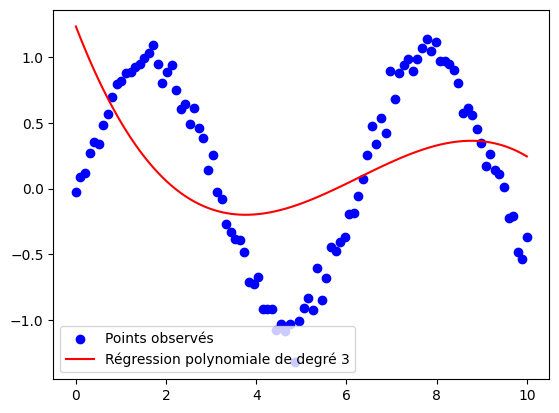

In [139]:
import numpy as np
import matplotlib.pyplot as plt

# Générer des données d'exemple (remplacez ceci par vos points)
x = np.linspace(0, 10, 100)  # 100 points sur l'intervalle [0, 10]
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)  # Sinus + bruit aléatoire

# Effectuer une régression polynomiale (par exemple, un polynôme de degré 3)
degre = 3
coefficients = np.polyfit(x, y, degre)

# Créer un modèle polynomial à partir des coefficients
polynome = np.poly1d(coefficients)

# Calculer les valeurs lissées
y_lisse = polynome(x)

# Tracer les données originales et la courbe lissée
plt.scatter(x, y, color='blue', label='Points observés')
plt.plot(x, y_lisse, color='red', label=f'Régression polynomiale de degré {degre}')
plt.legend()
plt.show()


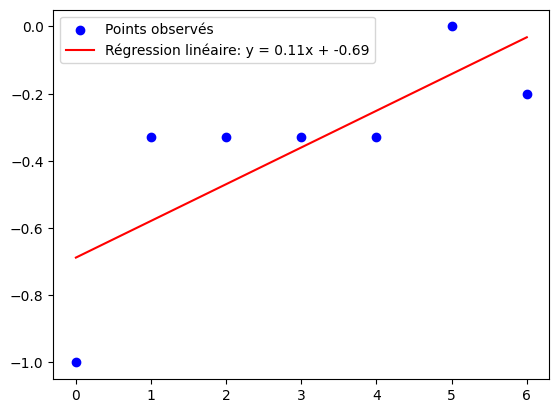

In [166]:
import numpy as np
import matplotlib.pyplot as plt

# Générer des données d'exemple (remplacez ceci par vos points)
x = df_copy["mspr"].index
y = df_copy["mspr"].values

# Calcul de la régression linéaire avec numpy (en utilisant la méthode des moindres carrés)
# y = a * x + b, où a est la pente et b l'ordonnée à l'origine
a, b = np.polyfit(x, y, 1)

# Calculer les valeurs lissées de y
y_lisse = a * x + b

# Tracer les points originaux et la droite ajustée
plt.scatter(x, y, color='blue', label='Points observés')
plt.plot(x, y_lisse, color='red', label=f'Régression linéaire: y = {a:.2f}x + {b:.2f}')
plt.legend()
plt.show()
